# 02 데이터 정리와 EDA

KNHANES 2017-2023 데이터를 합치고, 간단한 EDA를 진행한다.

## 1. 라이브러리 불러오기

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)

In [2]:
# Run once if needed
# !pip install pyreadstat seaborn

## 2. 데이터 불러오기

원본 .sav 파일은 GitHub에 올리지 않고, local folder에 두고 사용한다.

In [3]:
from pathlib import Path

data_dir = Path('분석데이터원본')
sav_files = sorted(data_dir.glob('HN*_all.sav'))

print(len(sav_files))
sav_files

7


[WindowsPath('분석데이터원본/HN17_all.sav'),
 WindowsPath('분석데이터원본/HN18_all.sav'),
 WindowsPath('분석데이터원본/HN19_all.sav'),
 WindowsPath('분석데이터원본/HN20_all.sav'),
 WindowsPath('분석데이터원본/HN21_all.sav'),
 WindowsPath('분석데이터원본/HN22_all.sav'),
 WindowsPath('분석데이터원본/HN23_all.sav')]

## 3. 주요 변수 선택

연구에 필요한 변수만 선택한다.

### 식이(영양) 변수 추가
교수님 피드백(변수 부족 · BMI와 허리둘레의 높은 상관)을 반영하여, KNHANES 영양조사의 **나트륨 섭취량(N_NA)** 과 **칼륨 섭취량(N_K)** 을 추가한다. 두 변수의 결측률은 약 15%로 30% 기준 이하이며, 비만 지표(BMI/허리둘레)와 공선성이 낮은 독립적인 생활·식이 차원을 제공한다.

In [4]:
use_cols = [
    'age', 'sex',
    'HE_BMI', 'HE_wc', 'HE_glu', 'HE_HbA1c', 'HE_TG', 'HE_chol',
    'sm_presnt', 'dr_month', 'pa_aerobic',
    'incm', 'educ',
    'HE_HPfh1', 'HE_HPfh2', 'HE_HPfh3', 'mh_stress',
    'HE_HDL_st2', 'HE_LDL_drct',
    'N_NA', 'N_K',  # 식이(영양) 변수 추가: 나트륨/칼륨 섭취량
    'HE_sbp', 'HE_dbp'
]


In [5]:
df_list = []

for file in sav_files:
    year = 2000 + int(file.name[2:4])
    print(file.name, year)
    
    temp = pd.read_spss(file)
    temp = temp[use_cols].copy()
    temp['year'] = year
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)
df.shape

HN17_all.sav 2017


HN18_all.sav 2018


HN19_all.sav 2019


HN20_all.sav 2020


HN21_all.sav 2021


HN22_all.sav 2022


HN23_all.sav 2023


(51872, 22)

In [6]:
df.head()

,age,sex,HE_BMI,HE_wc,HE_glu,HE_HbA1c,HE_TG,HE_chol,sm_presnt,dr_month,pa_aerobic,incm,educ,HE_HPfh1,HE_HPfh2,HE_HPfh3,mh_stress,HE_HDL_st2,HE_LDL_drct,HE_sbp,HE_dbp,year
0,76.0,1.0,21.483406,81.4,135.0,6.2,260.0,209.0,0.0,1.0,1.0,3.0,5.0,9.0,9.0,1.0,0.0,46.0,128.0,149.0,79.0,2017
1,69.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017
2,39.0,1.0,21.268015,75.7,85.0,5.2,93.0,172.0,1.0,1.0,0.0,1.0,7.0,1.0,1.0,0.0,1.0,55.0,NaN,115.0,78.0,2017
3,35.0,2.0,20.292201,77.6,86.0,5.6,98.0,172.0,0.0,1.0,0.0,1.0,7.0,1.0,1.0,0.0,0.0,59.0,NaN,105.0,75.0,2017
4,1.0,1.0,15.807612,48.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,88.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51872 entries, 0 to 51871
Data columns (total 22 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          51872 non-null  float64
 1   sex          51872 non-null  float64
 2   HE_BMI       49497 non-null  float64
 3   HE_wc        48073 non-null  float64
 4   HE_glu       44029 non-null  float64
 5   HE_HbA1c     43947 non-null  float64
 6   HE_TG        44030 non-null  float64
 7   HE_chol      44030 non-null  float64
 8   sm_presnt    40992 non-null  float64
 9   dr_month     44069 non-null  float64
 10  pa_aerobic   38653 non-null  float64
 11  incm         51677 non-null  float64
 12  educ         50054 non-null  float64
 13  HE_HPfh1     45033 non-null  float64
 14  HE_HPfh2     45033 non-null  float64
 15  HE_HPfh3     45033 non-null  float64
 16  mh_stress    44024 non-null  float64
 17  HE_HDL_st2   44018 non-null  float64
 18  HE_LDL_drct  15996 non-null  float64
 19  HE_s

## 4. COVID period 만들기

In [8]:
df['covid_period'] = 'before'
df.loc[df['year'].isin([2020, 2021]), 'covid_period'] = 'during'
df.loc[df['year'].isin([2022, 2023]), 'covid_period'] = 'after'

df[['year', 'covid_period']].head()

,year,covid_period
0,2017,before
1,2017,before
2,2017,before
3,2017,before
4,2017,before


## 5. 19-39세 대상자 선택

In [9]:
df_young = df[(df['age'] >= 19) & (df['age'] <= 39)].copy()

df_young.shape

(10974, 23)

In [10]:
df_young['age'].describe()

count    10974.000000
mean        29.846000
std          6.106588
min         19.000000
25%         25.000000
50%         30.000000
75%         35.000000
max         39.000000
Name: age, dtype: float64

## 5.5 특수 결측 코드 정리

KNHANES 변수 중 일부는 응답 거부, 모름, 해당 없음 등이 숫자 코드로 남아 있을 수 있다. 모델에서 하나의 정상 범주처럼 학습되지 않도록 확인된 특수 코드는 결측으로 바꾼다.


In [11]:
special_missing_codes = {
    'educ': [99],
    'HE_HPfh1': [9],
    'HE_HPfh2': [9],
    'HE_HPfh3': [8, 9]
}

for col, codes in special_missing_codes.items():
    before = df_young[col].isin(codes).sum()
    df_young[col] = df_young[col].replace(codes, np.nan)
    print(col, 'recode to missing:', before)


educ recode to missing: 321
HE_HPfh1 recode to missing: 190
HE_HPfh2 recode to missing: 168
HE_HPfh3 recode to missing: 603


## 6. Target 변수 만들기

고혈압 여부는 SBP/DBP로 만든다. 단, 모델에서는 SBP/DBP를 feature로 사용하지 않는다.

In [12]:
# Remove participants without BP measurements before target creation
before_bp_exclusion = len(df_young)
missing_bp_mask = df_young[['HE_sbp', 'HE_dbp']].isnull().any(axis=1)
excluded_missing_bp = int(missing_bp_mask.sum())

df_young = df_young.loc[~missing_bp_mask].copy()

# Assignment 3 main target: ACC/AHA 2017 definition (SBP >= 130 or DBP >= 80)
df_young['hypertension'] = 0
df_young.loc[(df_young['HE_sbp'] >= 130) | (df_young['HE_dbp'] >= 80), 'hypertension'] = 1

print('Before BP exclusion:', before_bp_exclusion)
print('Excluded missing SBP/DBP:', excluded_missing_bp)
print('Final cohort:', len(df_young))
print()
print(df_young['hypertension'].value_counts())
print()
print((df_young['hypertension'].value_counts(normalize=True) * 100).round(1))


Before BP exclusion: 10974
Excluded missing SBP/DBP: 655
Final cohort: 10319

hypertension
0    7947
1    2372
Name: count, dtype: int64

hypertension
0    77.0
1    23.0
Name: proportion, dtype: float64


## 7. 결측치 확인

In [13]:
df_young.isnull().sum()


age                0
sex                0
HE_BMI            39
HE_wc            127
HE_glu           219
HE_HbA1c         227
HE_TG            218
HE_chol          218
sm_presnt         52
dr_month          51
pa_aerobic       423
incm              29
educ             294
HE_HPfh1         262
HE_HPfh2         241
HE_HPfh3         672
mh_stress         51
HE_HDL_st2       221
HE_LDL_drct     7035
HE_sbp             0
HE_dbp             0
year               0
covid_period       0
hypertension       0
dtype: int64

In [14]:
missing_summary = (
    df_young.isnull().mean()
    .mul(100)
    .round(1)
    .reset_index()
)
missing_summary.columns = ['variable', 'missing_%']
missing_summary['decision'] = np.where(missing_summary['missing_%'] > 30, 'exclude', 'imputation allowed')
missing_summary



,variable,missing_%,decision
0,age,0.0,imputation allowed
1,sex,0.0,imputation allowed
2,HE_BMI,0.4,imputation allowed
3,HE_wc,1.2,imputation allowed
4,HE_glu,2.1,imputation allowed
5,HE_HbA1c,2.2,imputation allowed
6,HE_TG,2.1,imputation allowed
7,HE_chol,2.1,imputation allowed
8,sm_presnt,0.5,imputation allowed
9,dr_month,0.5,imputation allowed


## 8. 간단한 EDA

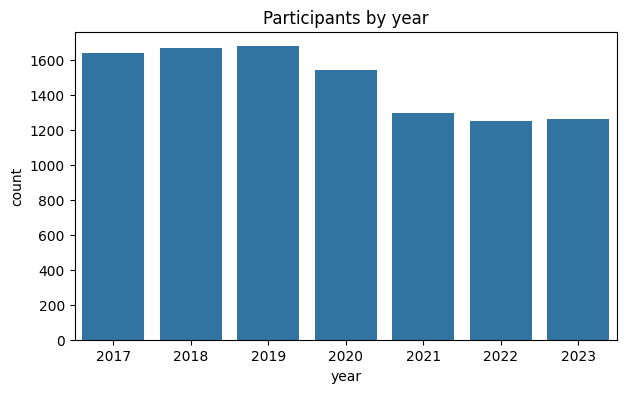

In [15]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df_young, x='year')
plt.title('Participants by year')
plt.show()

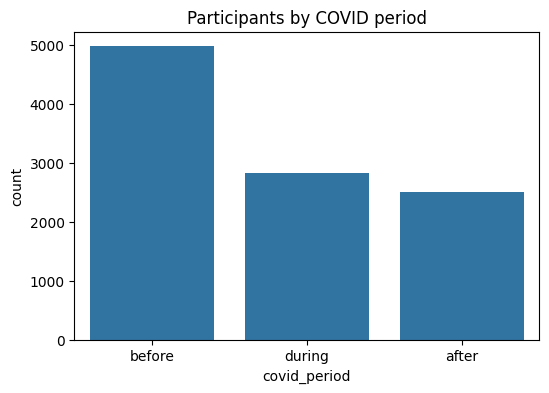

In [16]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_young, x='covid_period', order=['before', 'during', 'after'])
plt.title('Participants by COVID period')
plt.show()

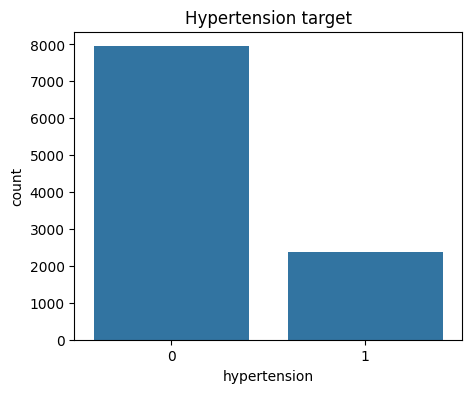

hypertension
0    0.770133
1    0.229867
Name: proportion, dtype: float64


In [17]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df_young, x='hypertension')
plt.title('Hypertension target')
plt.show()

print(df_young['hypertension'].value_counts(normalize=True))

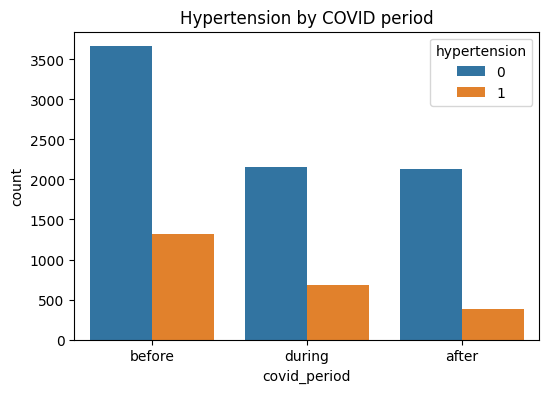

In [18]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_young, x='covid_period', hue='hypertension', order=['before', 'during', 'after'])
plt.title('Hypertension by COVID period')
plt.show()

고혈압 비율 확인

COVID period별로 고혈압 비율이 어떻게 다른지 표로 확인한다.

In [19]:
htn_period_ratio = pd.crosstab(
    df_young['covid_period'],
    df_young['hypertension'],
    normalize='index'
)

htn_period_ratio

hypertension,0,1
covid_period,,
after,0.848944,0.151056
before,0.736039,0.263961
during,0.760240,0.239760


고혈압이 있는 사람의 비율이 전체적으로 높지 않아 보인다. 그래서 모델링에서 class imbalance를 함께 고려한다.

조사 시기별 BMI 분포 확인

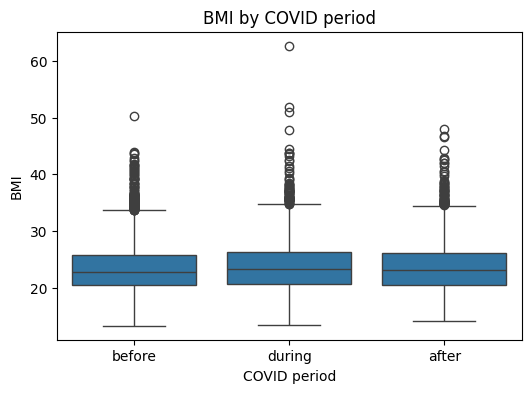

In [20]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_young, x='covid_period', y='HE_BMI', order=['before', 'during', 'after'])
plt.title('BMI by COVID period')
plt.xlabel('COVID period')
plt.ylabel('BMI')
plt.show()

조사 시기별 BMI 분포를 비교하면, 기간별로 약간의 차이가 보인다. 다만 covid_period는 측정환경 변화와 함께 묶여 있으므로 인과적으로 해석하지 않고, 모델의 contextual information으로만 확인한다.

Physical activity 변화 확인

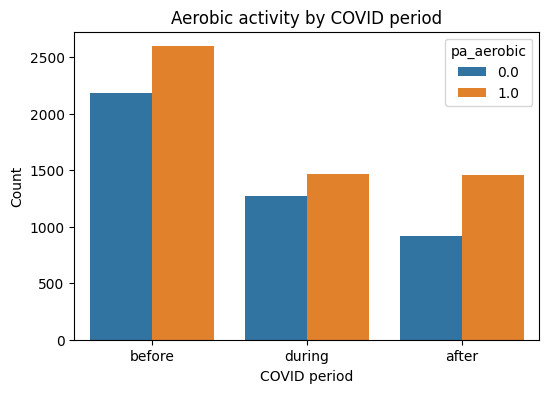

In [21]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_young, x='covid_period', hue='pa_aerobic', order=['before', 'during', 'after'])
plt.title('Aerobic activity by COVID period')
plt.xlabel('COVID period')
plt.ylabel('Count')
plt.show()

조사 시기별로 유산소 운동 여부의 분포가 달라지는지 간단히 확인했다. 이 차이는 COVID의 직접 효과로 해석하지 않는다.

간단히 확인해 보면, 19-39세 대상자 중에서는 고혈압이 있는 그룹이 상대적으로 적어 보인다. 따라서 모델링에서 class imbalance를 고려할 필요가 있다.

## 9. 수치형 변수 확인

In [22]:
numeric_cols = ['age', 'HE_BMI', 'HE_wc', 'HE_glu', 'HE_HbA1c', 'HE_TG', 'HE_chol', 'HE_sbp', 'HE_dbp']
df_young[numeric_cols].describe()


,age,HE_BMI,HE_wc,HE_glu,HE_HbA1c,HE_TG,HE_chol,HE_sbp,HE_dbp
count,10319.000000,10280.000000,10192.000000,10100.000000,10092.000000,10101.000000,10101.000000,10319.000000,10319.000000
mean,29.881868,23.687159,80.298195,92.606931,5.346859,114.798931,188.609445,111.103062,72.768679
std,6.113032,4.342608,12.016651,14.830713,0.515274,95.446678,34.023024,12.143193,9.655120
min,19.000000,13.332026,53.000000,54.000000,3.300000,19.000000,89.000000,76.000000,34.000000
25%,25.000000,20.559274,71.075000,86.000000,5.100000,63.000000,165.000000,102.500000,66.000000
50%,30.000000,22.988026,78.800000,91.000000,5.300000,89.000000,186.000000,110.000000,72.000000
75%,35.000000,26.022740,87.800000,96.000000,5.500000,136.000000,208.000000,118.000000,78.000000
max,39.000000,62.640542,147.500000,370.000000,14.900000,1895.000000,456.000000,197.000000,130.000000


주요 수치형 변수의 상관관계

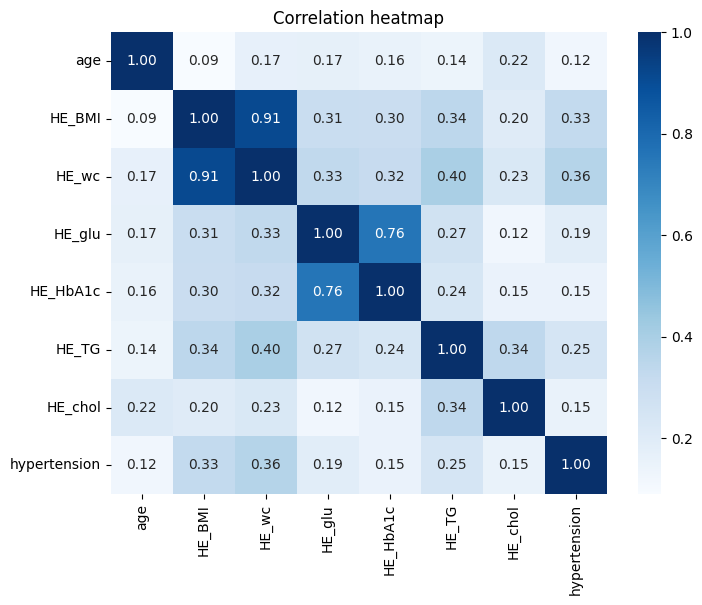

In [23]:
corr_cols = ['age', 'HE_BMI', 'HE_wc', 'HE_glu', 'HE_HbA1c', 'HE_TG', 'HE_chol', 'hypertension']

plt.figure(figsize=(8, 6))
sns.heatmap(df_young[corr_cols].corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation heatmap')
plt.show()


상관계수를 보면 BMI, 중성지방, 혈당 같은 건강 변수들이 고혈압 관련 변수와 일부 양의 관계를 보였다.

다만 상관계수가 매우 높은 편은 아니므로, 이 결과를 인과관계로 해석하기보다 모델에 사용할 변수를 확인하는 단계로 보았다.

BMI, glucose, triglycerides와 혈압 변수들의 관계를 간단히 확인했다. 다만 SBP/DBP는 target 생성에만 사용하고 모델 feature에서는 제외한다.

고혈압 여부에 따른 주요 변수 비교

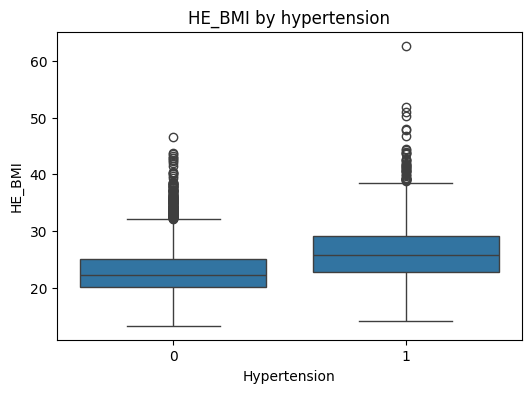

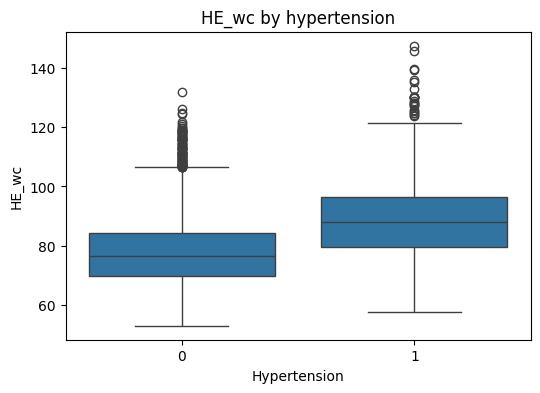

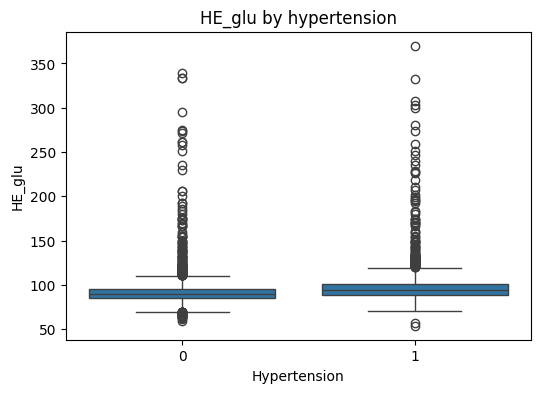

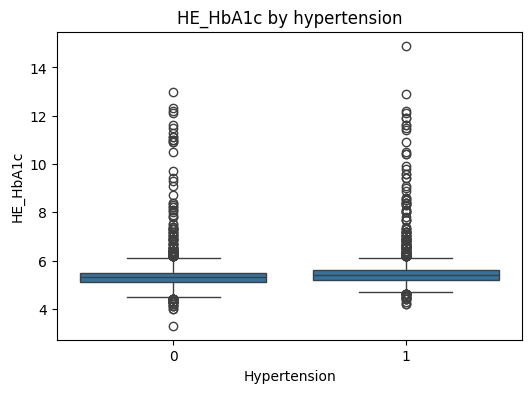

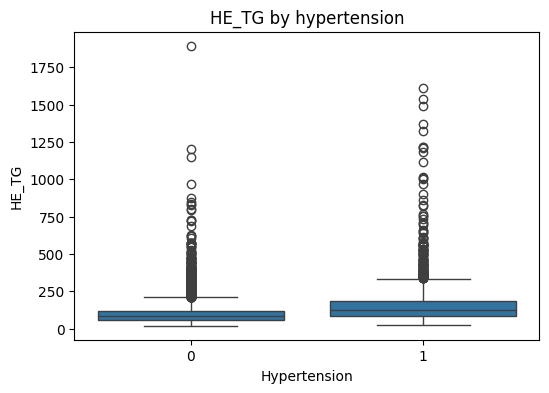

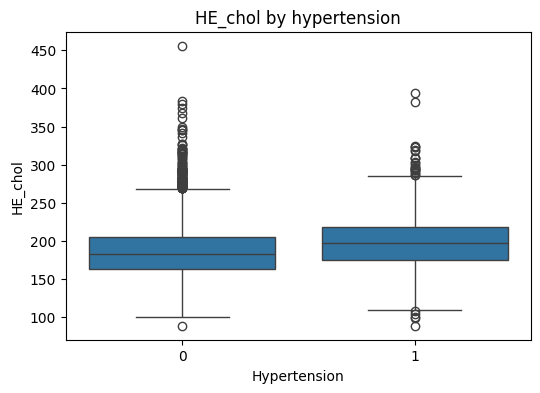

In [24]:
for col in ['HE_BMI', 'HE_wc', 'HE_glu', 'HE_HbA1c', 'HE_TG', 'HE_chol']:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df_young, x='hypertension', y=col)
    plt.title(col + ' by hypertension')
    plt.xlabel('Hypertension')
    plt.ylabel(col)
    plt.show()


고혈압 그룹과 비고혈압 그룹 사이에 BMI, glucose, triglycerides 분포가 조금 다르게 나타나는지 확인했다.

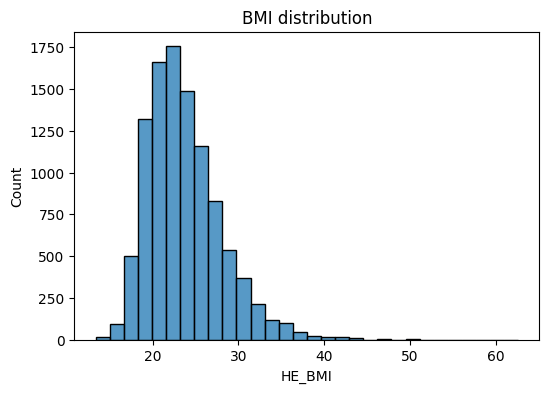

In [25]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df_young, x='HE_BMI', bins=30)
plt.title('BMI distribution')
plt.show()


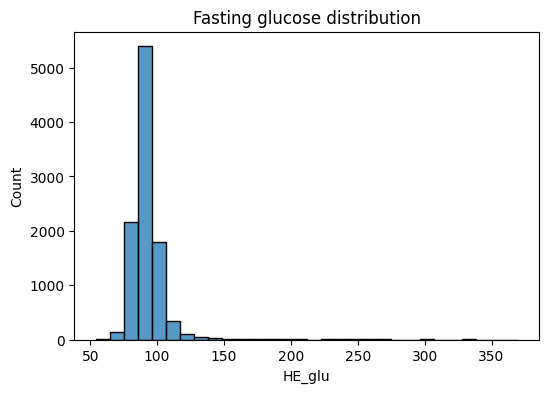

In [26]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df_young, x='HE_glu', bins=30)
plt.title('Fasting glucose distribution')
plt.show()


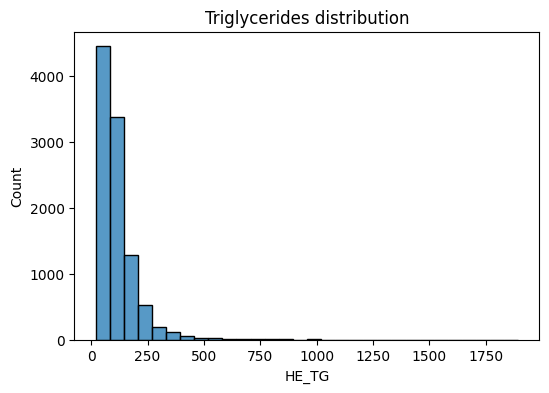

In [27]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df_young, x='HE_TG', bins=30)
plt.title('Triglycerides distribution')
plt.show()


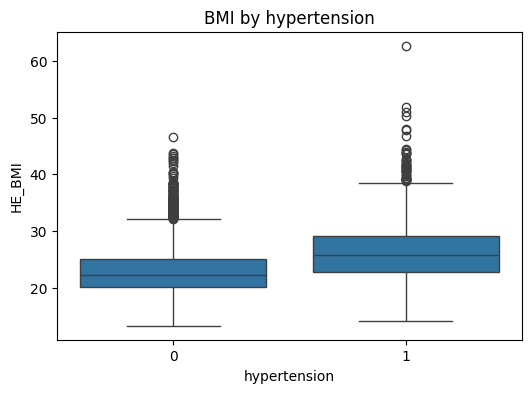

In [28]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_young, x='hypertension', y='HE_BMI')
plt.title('BMI by hypertension')
plt.show()

BMI, glucose, triglycerides는 사람마다 차이가 있고, 일부 값은 다른 값들보다 크게 나타난다. 래에서 histogram과 boxplot으로 간단히 확인한다.

## 10. 이상치 확인

이상치는 먼저 boxplot으로 확인한다. 필요하면 IQR 기준으로 대략 몇 개정도 있는지만 확인한다.

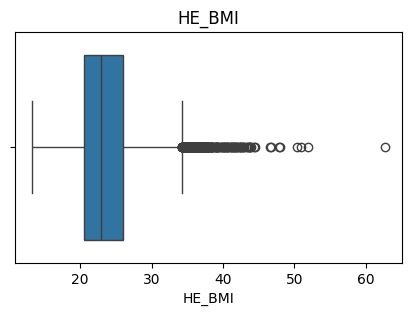

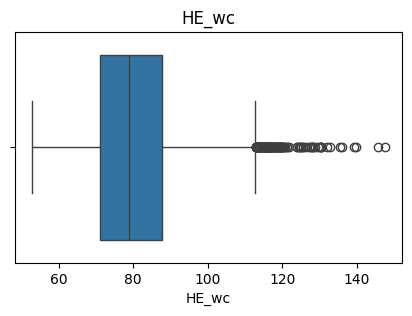

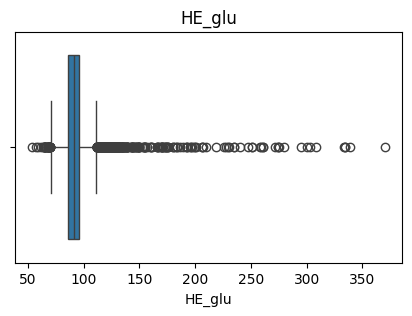

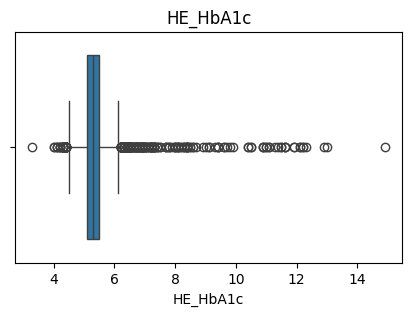

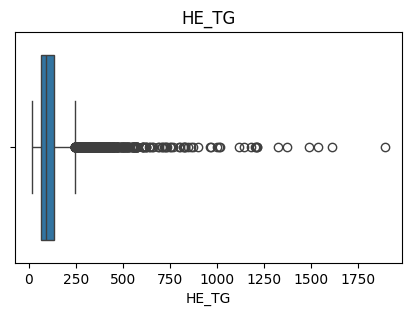

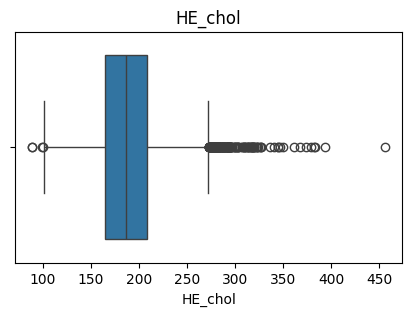

In [29]:
for col in ['HE_BMI', 'HE_wc', 'HE_glu', 'HE_HbA1c', 'HE_TG', 'HE_chol']:
    plt.figure(figsize=(5, 3))
    sns.boxplot(data=df_young, x=col)
    plt.title(col)
    plt.show()


수업에서 다룬 median과 IQR 개념을 사용해, 값이 너무 멀리 있는 경우가 얼마나 있는지만 간단히 확인한다.

In [30]:
iqr_summary = {}

for col in ['HE_BMI', 'HE_wc', 'HE_glu', 'HE_HbA1c', 'HE_TG', 'HE_chol']:
    q1 = df_young[col].quantile(0.25)
    q3 = df_young[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    outlier_count = ((df_young[col] < lower) | (df_young[col] > upper)).sum()
    iqr_summary[col] = int(outlier_count)

iqr_summary


{'HE_BMI': 245,
 'HE_wc': 128,
 'HE_glu': 429,
 'HE_HbA1c': 259,
 'HE_TG': 606,
 'HE_chol': 173}

## 11. 정리된 데이터 저장

In [31]:
output_dir = Path('processed_data')
output_dir.mkdir(exist_ok=True)

main_analysis_cols = [
    'age', 'sex',
    'HE_BMI', 'HE_wc', 'HE_glu', 'HE_HbA1c', 'HE_TG', 'HE_chol',
    'sm_presnt', 'dr_month', 'pa_aerobic',
    'incm', 'educ',
    'HE_HPfh1', 'HE_HPfh2', 'HE_HPfh3', 'mh_stress',
    'N_NA', 'N_K',  # 식이(영양) 변수
    'HE_sbp', 'HE_dbp', 'year', 'covid_period', 'hypertension'
]

# HDL은 측정 시기별 변화 가능성이 있어 주분석 모델 데이터에서 제외한다.
# LDL은 결측률이 30%를 초과하여 주분석에서 제외한다.
df_save = df_young[main_analysis_cols].copy()

save_path = output_dir / 'knhanes_young_hypertension_2017_2023.csv'
df_save.to_csv(save_path, index=False, encoding='utf-8-sig')

print('Saved:', save_path)
print('Shape:', df_save.shape)
save_path




Saved: processed_data\knhanes_young_hypertension_2017_2023.csv
Shape: (10319, 22)


WindowsPath('processed_data/knhanes_young_hypertension_2017_2023.csv')